# Transformer Model – Yahoo Finance
## CSV-Based Reproduction Version

This version is based on the uploaded repository notebook and the fixed **AAME (1).csv** dataset.

The goal is to preserve the original notebook's modeling logic while fixing execution errors and removing the dependency on live Yahoo Finance data for the AAME experiments.

### Important choices
- AAME data is loaded from the CSV instead of `yf.download()`.
- The CSV contains 2,518 rows from 2013-01-02 through 2022-12-30.
- The original LSTM and Transformer structure is preserved.
- The original code feeds a sequence length of **1** to both models; `num_time_steps = 10` is declared but not actually used.
- No random seed is set by default because the original repository did not set one. Therefore, model metrics can vary between runs.
- The Prophet section is retained separately because the original notebook uses AAPL/AAL there rather than AAME.


## 1. Install required packages


In [14]:
# Run once if needed. Restart the kernel after installation if Jupyter asks you to.
%pip install -q pandas numpy matplotlib seaborn plotly scikit-learn torch prophet yfinance


## 2. Imports


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

# yfinance is used only for the original notebook's separate Prophet examples.
import yfinance as yf


## 3. Load the exact AAME CSV dataset


In [16]:
# Path to the AAME dataset uploaded to Google Colab
CSV_PATH = "/content/AAME Dataset.csv"

# Make sure the file exists
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        "Could not find AAME Dataset.csv. "
        "Make sure the CSV is uploaded to the Colab session."
    )

# Load the dataset
stock_data = pd.read_csv(CSV_PATH)

# Convert Date from text to datetime
stock_data["Date"] = pd.to_datetime(stock_data["Date"])

# Match the column naming used later in the original notebook
stock_data.rename(columns={"Adj Close": "Adjusted Close"}, inplace=True)

# Display dataset information
print("Rows:", len(stock_data))
print("Date range:", stock_data["Date"].min(), "to", stock_data["Date"].max())
print("Columns:", stock_data.columns.tolist())

stock_data.head()


Rows: 2518
Date range: 2013-01-02 00:00:00 to 2022-12-30 00:00:00
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adjusted Close', 'Volume']


,Date,Open,High,Low,Close,Adjusted Close,Volume
0,2013-01-02,3.09,3.24,3.09,3.20,2.922022,3500
1,2013-01-03,3.19,3.32,3.09,3.20,2.922022,5500
2,2013-01-04,3.15,3.25,3.15,3.20,2.922022,3000
3,2013-01-07,3.20,3.23,3.05,3.23,2.949415,4700
4,2013-01-08,3.20,3.22,3.17,3.20,2.922022,3800


## 4. Plot historical AAME data


In [17]:
def plot_stock_data(data, title):
    '''Function for plotting stock data'''
    plot = px.line(
        data,
        x="Date",
        y="Close",
        hover_name="Date",
        line_shape="linear",
        title=title
    )
    return plot

plot_stock_data(stock_data[-30:], "AAME - Last 30 Trading Days")


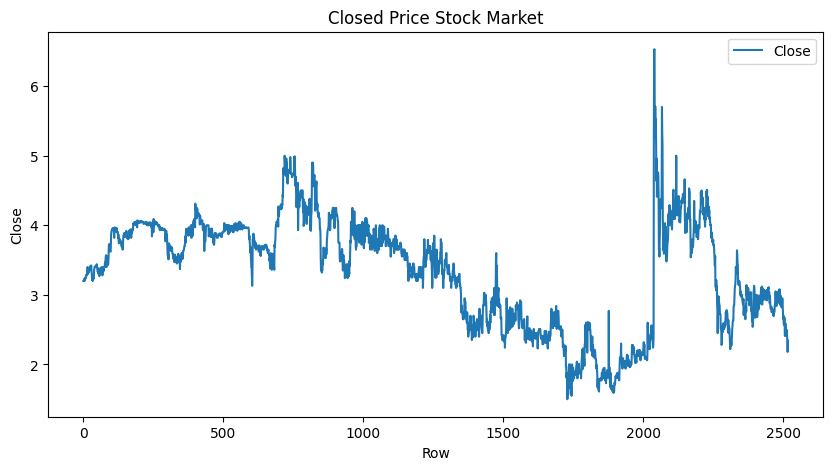

In [18]:
stock_data[["Close"]].plot(figsize=(10, 5))
plt.title("Closed Price Stock Market")
plt.xlabel("Row")
plt.ylabel("Close")
plt.show()


## 5. Outlier checking


In [19]:
# The original repository references df without defining it.
# Here df is explicitly defined as a copy of the AAME dataset.
df = stock_data.copy()

df["Date"] = pd.to_datetime(df["Date"])
df.head()


,Date,Open,High,Low,Close,Adjusted Close,Volume
0,2013-01-02,3.09,3.24,3.09,3.20,2.922022,3500
1,2013-01-03,3.19,3.32,3.09,3.20,2.922022,5500
2,2013-01-04,3.15,3.25,3.15,3.20,2.922022,3000
3,2013-01-07,3.20,3.23,3.05,3.23,2.949415,4700
4,2013-01-08,3.20,3.22,3.17,3.20,2.922022,3800


In [20]:
# Open-price outliers using the original IQR method.
column_name = "Open"

Q1 = df[column_name].quantile(0.25)
Q3 = df[column_name].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df[column_name] < lower_bound) |
    (df[column_name] > upper_bound)
]

num_outliers = len(outliers)
print(f"Number of outliers in {column_name}: {num_outliers}")


Number of outliers in Open: 2


In [21]:
# Close-price outliers using the original IQR method.
column_name = "Close"

Q1 = df[column_name].quantile(0.25)
Q3 = df[column_name].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df[column_name] < lower_bound) |
    (df[column_name] > upper_bound)
]

num_outliers = len(outliers)
print(f"Number of outliers in {column_name}: {num_outliers}")


Number of outliers in Close: 2


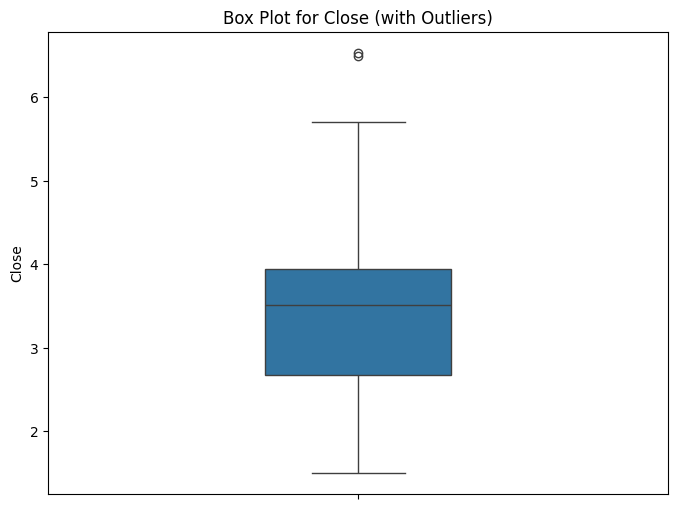

In [22]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df["Close"], width=0.3)
plt.title("Box Plot for Close (with Outliers)")
plt.ylabel("Close")
plt.show()


## 6. Shared preprocessing for LSTM and Transformer

This reproduces the original repository's preprocessing:
- Normalize `Low`, `Open`, `Volume`, `High`, `Close`, and adjusted close using the mean and standard deviation of the full dataset.
- Use `Low`, `Open`, and `High` as model inputs.
- Predict `Close`.
- Split chronologically into 70% training, 15% validation, and 15% testing.

The repository renames `Adj Close` to `Adjusted Close`, so this notebook does the same.


In [23]:
def prepare_aame_data(stock_data_input):
    data_for_model = stock_data_input.copy()
    data_for_model = data_for_model.set_index("Date")

    columns_to_normalize = [
        "Low",
        "Open",
        "Volume",
        "High",
        "Close",
        "Adjusted Close"
    ]

    data_to_normalize = data_for_model[columns_to_normalize].values

    tensor_data = torch.tensor(data_to_normalize, dtype=torch.float32)

    mean = tensor_data.mean(dim=0)
    std = tensor_data.std(dim=0)

    normalized_data = (tensor_data - mean) / std

    df_normalized = pd.DataFrame(
        normalized_data.numpy(),
        columns=columns_to_normalize
    )

    df_normalized["Date"] = data_for_model.index.to_numpy()
    data = df_normalized

    train_percent = 0.70
    val_percent = 0.15
    test_percent = 0.15

    train_size = int(train_percent * len(data))
    val_size = int(val_percent * len(data))
    test_size = len(data) - train_size - val_size

    train_data = data.iloc[:train_size]
    val_data = data.iloc[train_size:train_size + val_size]
    test_data = data.iloc[train_size + val_size:]

    feature_columns = ["Low", "Open", "High"]
    target_column = "Close"

    train_features = torch.tensor(
        train_data[feature_columns].values,
        dtype=torch.float32
    )
    train_target = torch.tensor(
        train_data[target_column].values,
        dtype=torch.float32
    )

    val_features = torch.tensor(
        val_data[feature_columns].values,
        dtype=torch.float32
    )
    val_target = torch.tensor(
        val_data[target_column].values,
        dtype=torch.float32
    )

    test_features = torch.tensor(
        test_data[feature_columns].values,
        dtype=torch.float32
    )
    test_target = torch.tensor(
        test_data[target_column].values,
        dtype=torch.float32
    )

    return (
        train_features, train_target,
        val_features, val_target,
        test_features, test_target,
        feature_columns
    )


(
    train_features,
    train_target,
    val_features,
    val_target,
    test_features,
    test_target,
    feature_columns
) = prepare_aame_data(stock_data)

print("Training features:", train_features.shape)
print("Validation features:", val_features.shape)
print("Test features:", test_features.shape)


Training features: torch.Size([1762, 3])
Validation features: torch.Size([377, 3])
Test features: torch.Size([379, 3])


## 7. Hyperparameters


In [24]:
input_size = len(feature_columns)
hidden_size = 64
output_size = 1
num_layers = 2
num_attention_heads = 4
learning_rate = 0.001
num_epochs = 100

# This variable exists in the original notebook,
# but the original code never constructs 10-day sequences from it.
num_time_steps = 10


## 8. LSTM

No seed is set here because the original repository does not set one.  
Therefore, your exact loss and metric values can change every time the cell is rerun.


In [25]:
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
        )
        self.fc_output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        _, (hn, cn) = self.lstm(x)
        x = self.fc_output(hn[-1, :, :])
        return x


hidden_size_lstm = 64
num_layers_lstm = 2

model_lstm = LSTMModel(
    input_size,
    hidden_size_lstm,
    output_size,
    num_layers_lstm
)

criterion = nn.MSELoss()
optimizer_lstm = optim.Adam(
    model_lstm.parameters(),
    lr=learning_rate
)

train_losses_lstm = []
val_losses_lstm = []
test_losses_lstm = []

for epoch in range(num_epochs):
    model_lstm.train()
    optimizer_lstm.zero_grad()

    # This is exactly the sequence structure used by the original:
    # [samples, 3 features] -> [samples, 1 time step, 3 features]
    outputs_lstm = model_lstm(train_features.unsqueeze(1))

    loss_lstm = criterion(
        outputs_lstm,
        train_target.unsqueeze(1)
    )

    loss_lstm.backward()
    optimizer_lstm.step()

    train_losses_lstm.append(loss_lstm.item())

    model_lstm.eval()

    with torch.no_grad():
        val_outputs_lstm = model_lstm(val_features.unsqueeze(1))
        val_loss_lstm = criterion(
            val_outputs_lstm,
            val_target.unsqueeze(1)
        )

        test_outputs_lstm = model_lstm(test_features.unsqueeze(1))
        test_loss_lstm = criterion(
            test_outputs_lstm,
            test_target.unsqueeze(1)
        )

    val_losses_lstm.append(val_loss_lstm.item())
    test_losses_lstm.append(test_loss_lstm.item())

    print(
        f"Epoch [{epoch + 1}/{num_epochs}], "
        f"Training Loss (LSTM): {loss_lstm.item():.4f}, "
        f"Validation Loss (LSTM): {val_loss_lstm.item():.4f}, "
        f"Test Loss (LSTM): {test_loss_lstm.item():.4f}"
    )


Epoch [1/100], Training Loss (LSTM): 0.7320, Validation Loss (LSTM): 2.5838, Test Loss (LSTM): 0.6550
Epoch [2/100], Training Loss (LSTM): 0.7265, Validation Loss (LSTM): 2.5800, Test Loss (LSTM): 0.6533
Epoch [3/100], Training Loss (LSTM): 0.7211, Validation Loss (LSTM): 2.5762, Test Loss (LSTM): 0.6516
Epoch [4/100], Training Loss (LSTM): 0.7158, Validation Loss (LSTM): 2.5723, Test Loss (LSTM): 0.6499
Epoch [5/100], Training Loss (LSTM): 0.7105, Validation Loss (LSTM): 2.5684, Test Loss (LSTM): 0.6483
Epoch [6/100], Training Loss (LSTM): 0.7052, Validation Loss (LSTM): 2.5643, Test Loss (LSTM): 0.6466
Epoch [7/100], Training Loss (LSTM): 0.6999, Validation Loss (LSTM): 2.5600, Test Loss (LSTM): 0.6449
Epoch [8/100], Training Loss (LSTM): 0.6945, Validation Loss (LSTM): 2.5554, Test Loss (LSTM): 0.6432
Epoch [9/100], Training Loss (LSTM): 0.6891, Validation Loss (LSTM): 2.5503, Test Loss (LSTM): 0.6413
Epoch [10/100], Training Loss (LSTM): 0.6836, Validation Loss (LSTM): 2.5448, Test

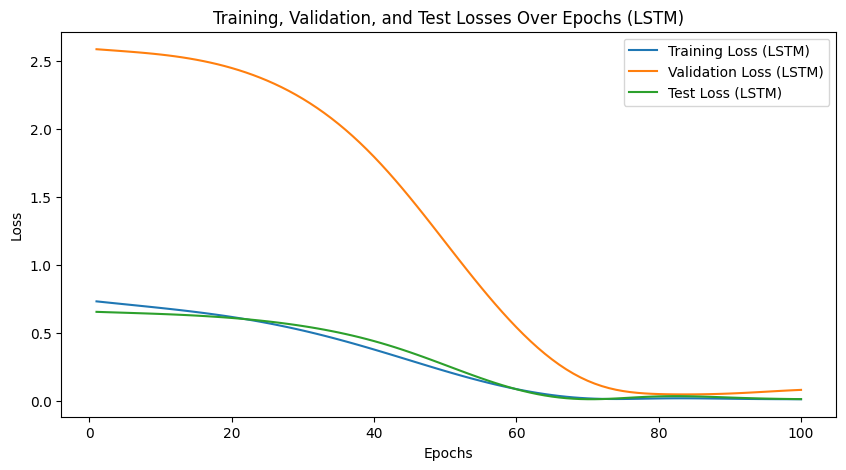

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, num_epochs + 1),
    train_losses_lstm,
    label="Training Loss (LSTM)"
)
plt.plot(
    range(1, num_epochs + 1),
    val_losses_lstm,
    label="Validation Loss (LSTM)"
)
plt.plot(
    range(1, num_epochs + 1),
    test_losses_lstm,
    label="Test Loss (LSTM)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training, Validation, and Test Losses Over Epochs (LSTM)")
plt.legend()
plt.show()


In [27]:
model_lstm.eval()

with torch.no_grad():
    val_predictions_lstm = model_lstm(
        val_features.unsqueeze(1)
    ).squeeze(1).numpy()

mae_val_lstm = mean_absolute_error(
    val_target.numpy(),
    val_predictions_lstm
)
mse_val_lstm = mean_squared_error(
    val_target.numpy(),
    val_predictions_lstm
)
rmse_val_lstm = np.sqrt(mse_val_lstm)
mape_val_lstm = calculate_mape(
    val_target.numpy(),
    val_predictions_lstm
)

print("Validation Set Metrics (LSTM):")
print(f"Mean Absolute Error (MAE): {mae_val_lstm:.4f}")
print(f"Mean Squared Error (MSE): {mse_val_lstm:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_val_lstm:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_val_lstm:.4f}")
print()

with torch.no_grad():
    test_predictions_lstm = model_lstm(
        test_features.unsqueeze(1)
    ).squeeze(1).numpy()

mae_test_lstm = mean_absolute_error(
    test_target.numpy(),
    test_predictions_lstm
)
mse_test_lstm = mean_squared_error(
    test_target.numpy(),
    test_predictions_lstm
)
rmse_test_lstm = np.sqrt(mse_test_lstm)
mape_test_lstm = calculate_mape(
    test_target.numpy(),
    test_predictions_lstm
)
r2_lstm = r2_score(
    test_target.numpy(),
    test_predictions_lstm
)

print("Test Set Metrics (LSTM):")
print(f"Mean Absolute Error (MAE): {mae_test_lstm:.4f}")
print(f"Mean Squared Error (MSE): {mse_test_lstm:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test_lstm:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_test_lstm:.4f}")
print(f"R-squared: {r2_lstm:.6f}")


Validation Set Metrics (LSTM):
Mean Absolute Error (MAE): 0.2206
Mean Squared Error (MSE): 0.0819
Root Mean Squared Error (RMSE): 0.2862
Mean Absolute Percentage Error (MAPE): 14.3440

Test Set Metrics (LSTM):
Mean Absolute Error (MAE): 0.0923
Mean Squared Error (MSE): 0.0140
Root Mean Squared Error (RMSE): 0.1185
Mean Absolute Percentage Error (MAPE): 20.3650
R-squared: 0.978004


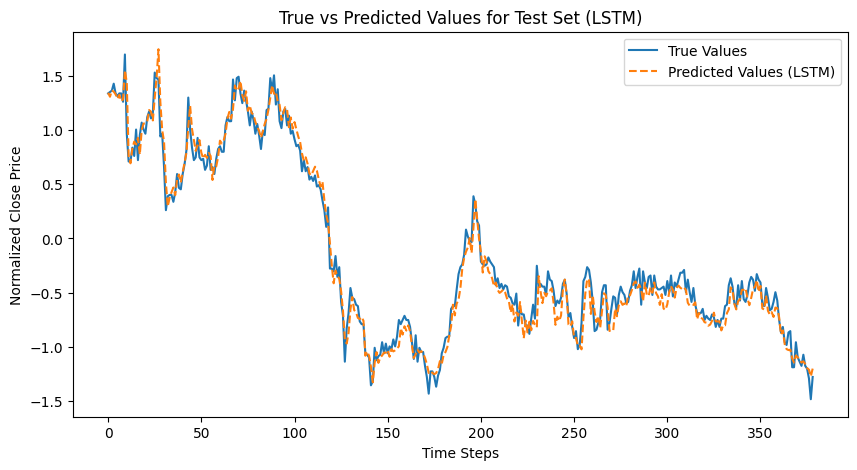

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(test_target.numpy(), label="True Values")
plt.plot(
    test_predictions_lstm,
    label="Predicted Values (LSTM)",
    linestyle="dashed"
)
plt.xlabel("Time Steps")
plt.ylabel("Normalized Close Price")
plt.title("True vs Predicted Values for Test Set (LSTM)")
plt.legend()
plt.show()


## 9. Prophet section from the original notebook

The original notebook switches away from AAME here:
- It first retrieves AAPL.
- It then trains Prophet on AAL.

Those datasets are not contained in the uploaded AAME CSV, so this section still uses Yahoo Finance.  
This section is separate from the AAME LSTM/Transformer experiment.


In [29]:
# Original AAPL setup
stock_ticker = "AAPL"
yfin = yf.Ticker(stock_ticker)
data_aapl = yfin.history(period="max")

data_aapl = data_aapl[["Close"]]
data_aapl.reset_index(level=0, inplace=True)
data_aapl = data_aapl.rename(
    {"Date": "ds", "Close": "y"},
    axis="columns"
)

# Prophet does not accept timezone-aware ds values.
if hasattr(data_aapl["ds"].dt, "tz") and data_aapl["ds"].dt.tz is not None:
    data_aapl["ds"] = data_aapl["ds"].dt.tz_localize(None)

data_aapl.tail()


,ds,y
11520,2026-08-31,316.850006
11521,2026-09-01,325.130005
11522,2026-09-02,324.959991
11523,2026-09-03,328.209991
11524,2026-09-04,318.684998


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


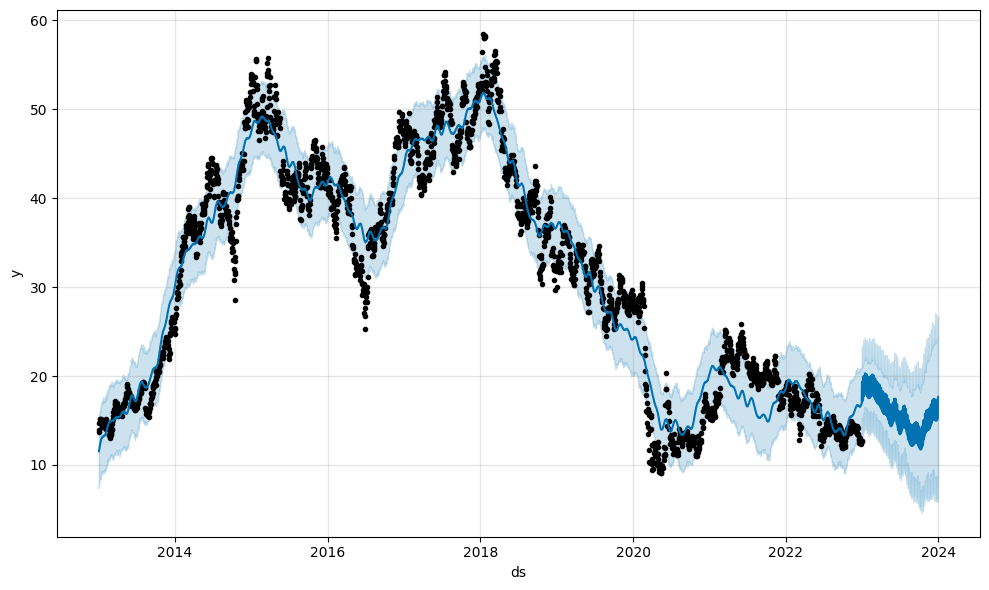

In [30]:
# Original Prophet experiment uses American Airlines (AAL).
stock_symbol_prophet = "AAL"
start_date_prophet = "2013-01-01"
end_date_prophet = "2023-01-01"

stock_data_prophet = yf.download(
    stock_symbol_prophet,
    start=start_date_prophet,
    end=end_date_prophet,
    auto_adjust=False,
    progress=False
)

# Current yfinance versions may return MultiIndex columns.
if isinstance(stock_data_prophet.columns, pd.MultiIndex):
    stock_data_prophet.columns = stock_data_prophet.columns.get_level_values(0)

stock_data_prophet.reset_index(inplace=True)

prophet_data = stock_data_prophet[["Date", "Close"]].copy()
prophet_data.rename(
    columns={"Date": "ds", "Close": "y"},
    inplace=True
)

model_prophet = Prophet()
model_prophet.fit(prophet_data)

future = model_prophet.make_future_dataframe(periods=365)
forecast = model_prophet.predict(future)

model_prophet.plot(forecast)
plt.show()


In [31]:
print(
    forecast[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ].tail()
)


             ds       yhat  yhat_lower  yhat_upper
2878 2023-12-26  15.128964    6.153054   24.157097
2879 2023-12-27  15.175495    5.968161   24.332401
2880 2023-12-28  15.182943    6.444219   24.586067
2881 2023-12-29  15.245926    5.882099   24.957913
2882 2023-12-30  17.632324    8.280428   26.664239


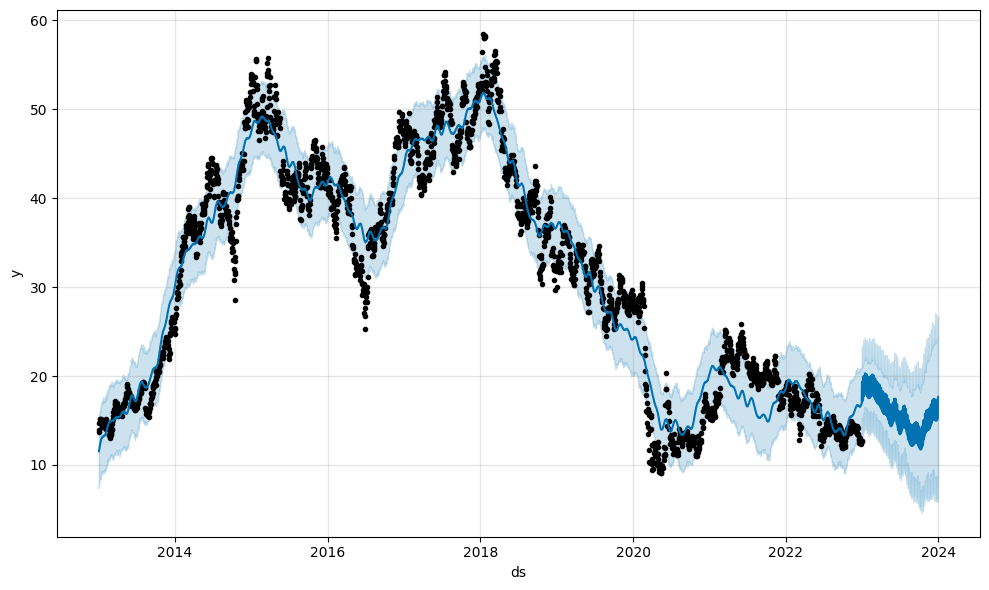

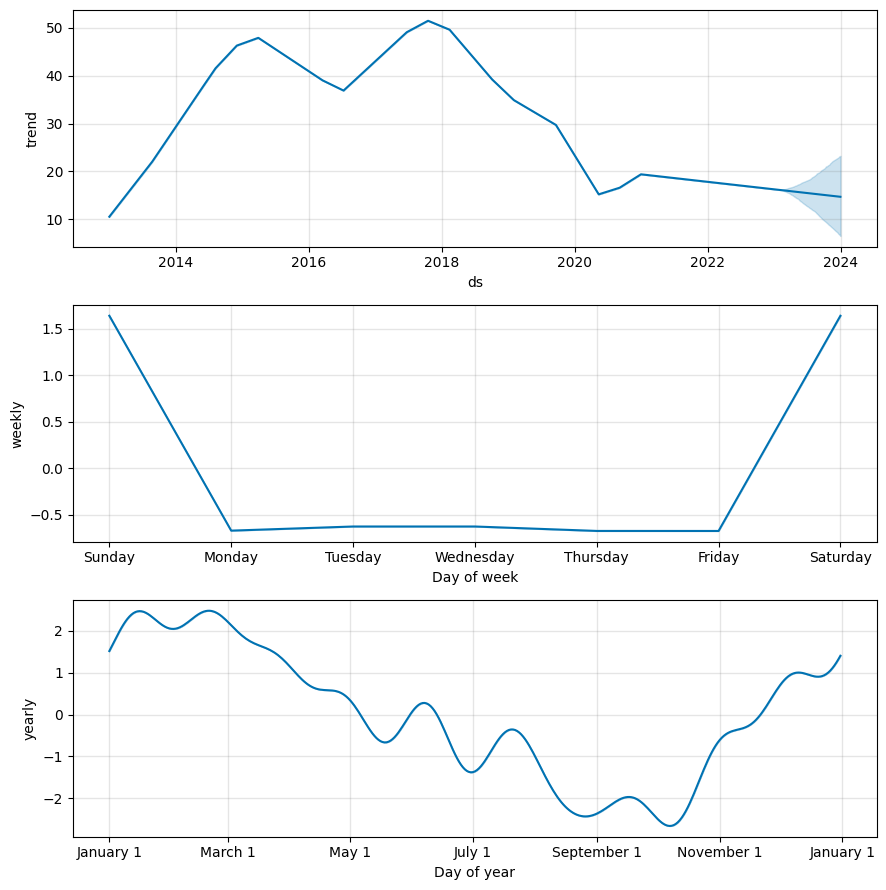

In [32]:
figure1 = model_prophet.plot(forecast)
plt.show()

figure2 = model_prophet.plot_components(forecast)
plt.show()


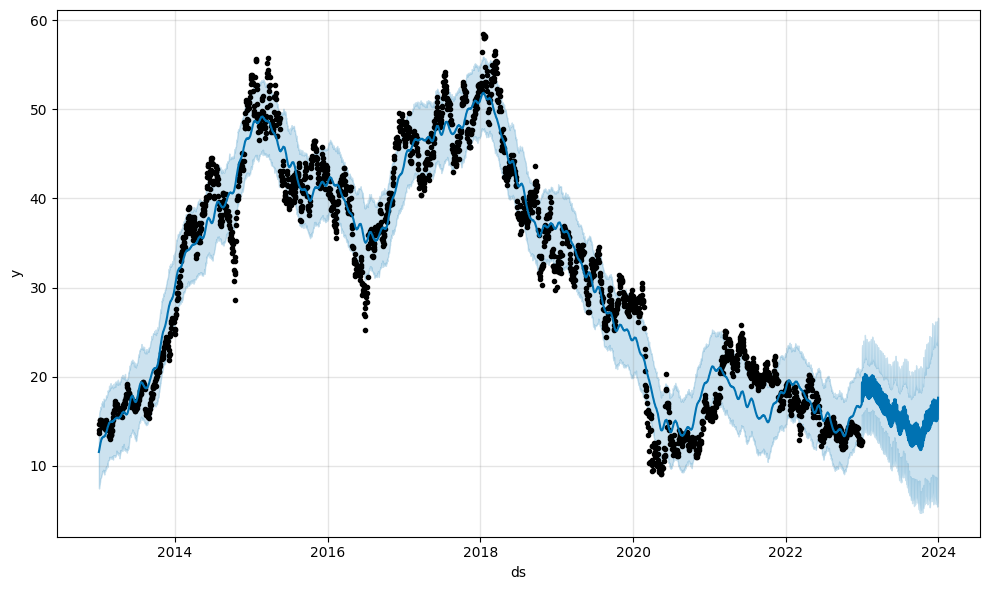

In [34]:
# Generate forecast
forecast = model_prophet.predict(future)

# Plot forecast
fig = model_prophet.plot(forecast)
plt.show()


## 10. Transformer

This section again uses the fixed AAME CSV data.

As in the original repository, no random seed is set.  
The original Transformer is also given a sequence length of 1 rather than a 10-day historical window.


In [35]:
class TransformerModel(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        output_size,
        num_layers,
        num_attention_heads
    ):
        super(TransformerModel, self).__init__()

        self.embedding = nn.Linear(
            input_size,
            hidden_size
        )

        self.transformer = nn.Transformer(
            d_model=hidden_size,
            nhead=num_attention_heads,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers
        )

        self.fc_output = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(1, 0, 2)
        x = self.transformer(x, x)
        x = x.permute(1, 0, 2)
        x = self.fc_output(x[:, -1, :])
        return x


model = TransformerModel(
    input_size,
    hidden_size,
    output_size,
    num_layers,
    num_attention_heads
)

criterion = nn.MSELoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

train_losses = []
val_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(
        train_features.unsqueeze(1)
    )

    loss = criterion(
        outputs,
        train_target.unsqueeze(1)
    )

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    model.eval()

    with torch.no_grad():
        val_outputs = model(
            val_features.unsqueeze(1)
        )
        val_loss = criterion(
            val_outputs,
            val_target.unsqueeze(1)
        )

        test_outputs = model(
            test_features.unsqueeze(1)
        )
        test_loss = criterion(
            test_outputs,
            test_target.unsqueeze(1)
        )

    val_losses.append(val_loss.item())
    test_losses.append(test_loss.item())

    print(
        f"Epoch [{epoch + 1}/{num_epochs}], "
        f"Training Loss: {loss.item():.4f}, "
        f"Validation Loss: {val_loss.item():.4f}, "
        f"Test Loss: {test_loss.item():.4f}"
    )


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:144: UserWarning:

enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)



Epoch [1/100], Training Loss: 1.9056, Validation Loss: 0.6660, Test Loss: 1.0289
Epoch [2/100], Training Loss: 1.8966, Validation Loss: 0.4241, Test Loss: 0.9479
Epoch [3/100], Training Loss: 0.5942, Validation Loss: 0.2082, Test Loss: 0.4061
Epoch [4/100], Training Loss: 0.2009, Validation Loss: 0.7719, Test Loss: 0.1745
Epoch [5/100], Training Loss: 0.2933, Validation Loss: 1.5841, Test Loss: 0.2655
Epoch [6/100], Training Loss: 0.3329, Validation Loss: 1.8825, Test Loss: 0.3638
Epoch [7/100], Training Loss: 0.3572, Validation Loss: 1.5869, Test Loss: 0.2846
Epoch [8/100], Training Loss: 0.2946, Validation Loss: 1.0200, Test Loss: 0.1217
Epoch [9/100], Training Loss: 0.1866, Validation Loss: 0.5156, Test Loss: 0.0441
Epoch [10/100], Training Loss: 0.0980, Validation Loss: 0.2509, Test Loss: 0.1318
Epoch [11/100], Training Loss: 0.0896, Validation Loss: 0.1797, Test Loss: 0.2794
Epoch [12/100], Training Loss: 0.1148, Validation Loss: 0.1665, Test Loss: 0.3343
Epoch [13/100], Training 

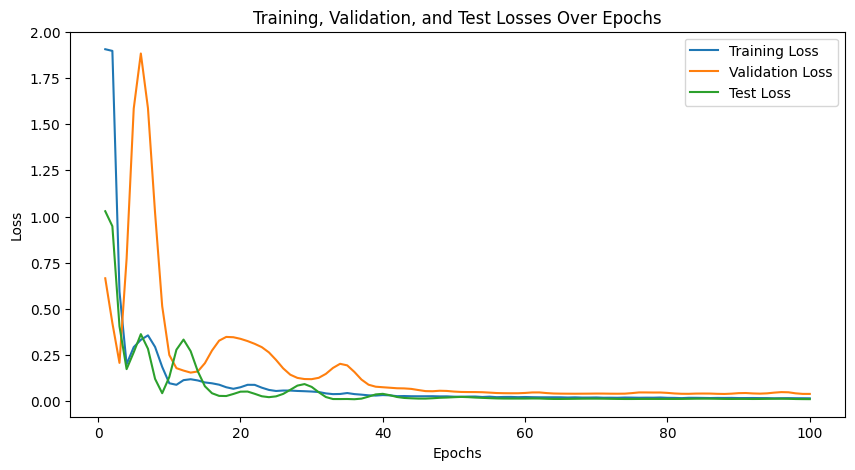

Final Test Loss: 0.0120


In [36]:
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    label="Training Loss"
)
plt.plot(
    range(1, num_epochs + 1),
    val_losses,
    label="Validation Loss"
)
plt.plot(
    range(1, num_epochs + 1),
    test_losses,
    label="Test Loss"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training, Validation, and Test Losses Over Epochs")
plt.legend()
plt.show()

print(f"Final Test Loss: {test_losses[-1]:.4f}")


In [37]:
model.eval()

with torch.no_grad():
    val_predictions = model(
        val_features.unsqueeze(1)
    ).squeeze(1).numpy()

val_target_numpy = val_target.numpy()

mae_val = mean_absolute_error(
    val_target_numpy,
    val_predictions
)
mse_val = mean_squared_error(
    val_target_numpy,
    val_predictions
)
rmse_val = np.sqrt(mse_val)
mape_val = calculate_mape(
    val_target_numpy,
    val_predictions
)

print("Validation Set Metrics:")
print(f"Mean Absolute Error (MAE): {mae_val:.4f}")
print(f"Mean Squared Error (MSE): {mse_val:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_val:.4f}")
print()

with torch.no_grad():
    test_predictions = model(
        test_features.unsqueeze(1)
    ).squeeze(1).numpy()

test_target_numpy = test_target.numpy()

mae_test = mean_absolute_error(
    test_target_numpy,
    test_predictions
)
mse_test = mean_squared_error(
    test_target_numpy,
    test_predictions
)
rmse_test = np.sqrt(mse_test)
mape_test = calculate_mape(
    test_target_numpy,
    test_predictions
)
r2_transformer = r2_score(
    test_target_numpy,
    test_predictions
)

print("Test Set Metrics:")
print(f"Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"Mean Squared Error (MSE): {mse_test:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_test:.4f}")
print(f"R-squared: {r2_transformer:.6f}")


Validation Set Metrics:
Mean Absolute Error (MAE): 0.1081
Mean Squared Error (MSE): 0.0403
Root Mean Squared Error (RMSE): 0.2008
Mean Absolute Percentage Error (MAPE): 8.2336

Test Set Metrics:
Mean Absolute Error (MAE): 0.0791
Mean Squared Error (MSE): 0.0120
Root Mean Squared Error (RMSE): 0.1096
Mean Absolute Percentage Error (MAPE): 15.8265
R-squared: 0.981187


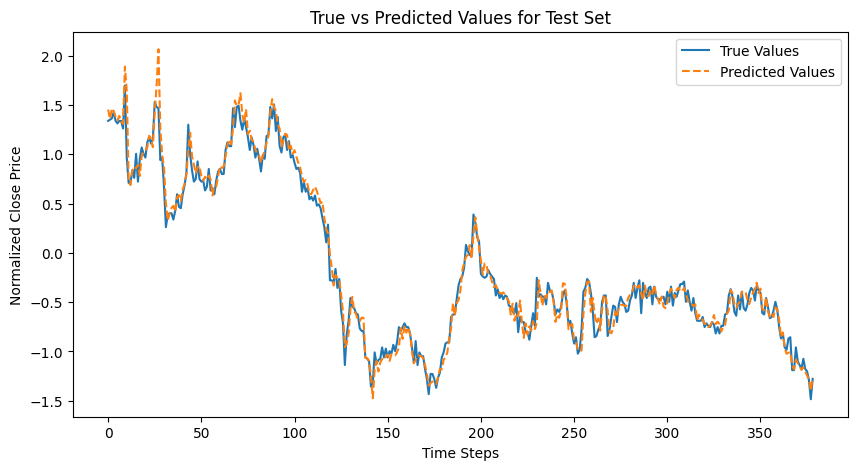

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(
    test_target_numpy,
    label="True Values"
)
plt.plot(
    test_predictions,
    label="Predicted Values",
    linestyle="dashed"
)
plt.xlabel("Time Steps")
plt.ylabel("Normalized Close Price")
plt.title("True vs Predicted Values for Test Set")
plt.legend()
plt.show()


## Reproducibility note

The AAME input data is now fixed because it comes from the uploaded CSV instead of a live Yahoo Finance download.

However, the LSTM and Transformer numerical outputs are **not expected to match the repository exactly**, because the repository does not record a random seed. Each model can therefore begin from different randomly initialized weights.

If you later want your own runs to be identical to one another, add this before constructing each model:

```python
torch.manual_seed(42)
np.random.seed(42)
```

That would make your experiment more reproducible, but it would not recreate the unknown random state used for the repository's saved results.
